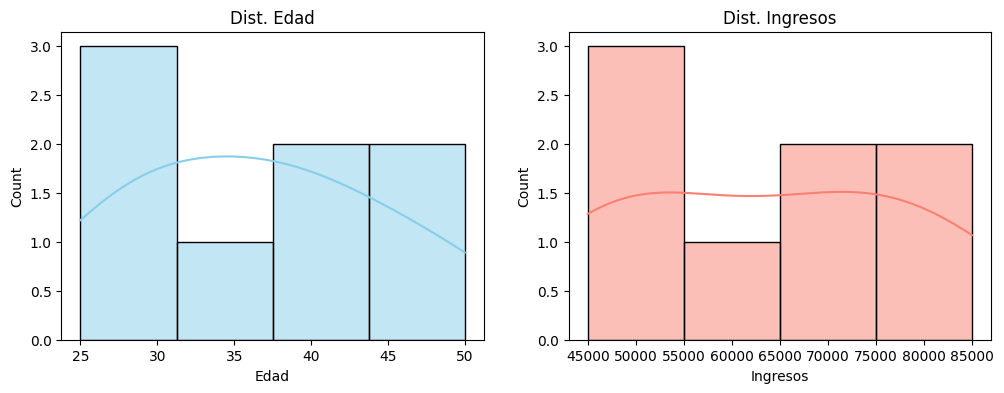

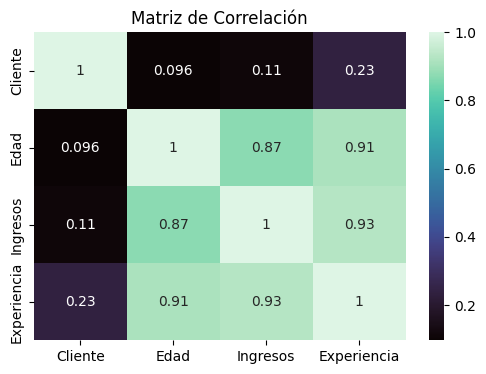

Número de componentes para el 90% de varianza: 1


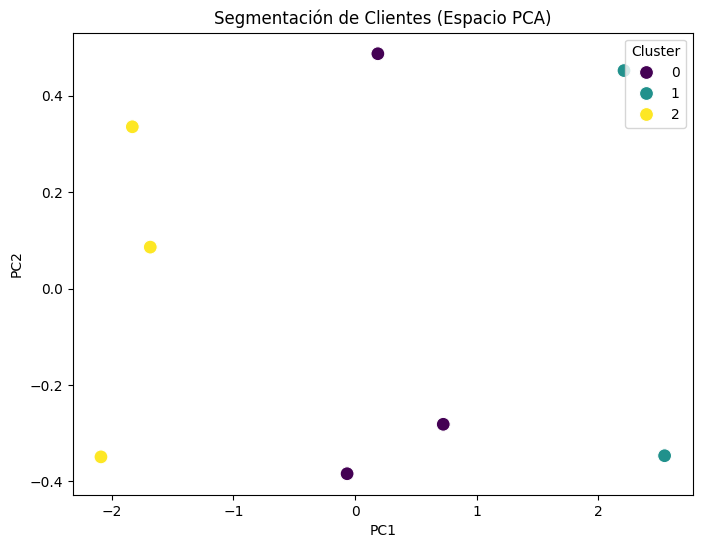


Asignación final de clusters:
   Cliente  Edad  Ingresos  Cluster
0        1    25     50000        2
1        2    40     60000        0
2        3    35     70000        0
3        4    50     80000        1
4        5    30     45000        2
5        6    45     85000        1
6        7    38     72000        0
7        8    29     48000        2


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Crear DataFrame
df = pd.DataFrame({
    "Cliente":     [1, 2, 3, 4, 5, 6, 7, 8],
    "Edad":        [25, 40, 35, 50, 30, 45, 38, 29],
    "Ingresos":    [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    "Experiencia": [2, 10, 7, 15, 3, 20, 12, 4]
})

# 1) Análisis Exploratorio
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Edad"], kde=True, ax=axes[0], color="skyblue").set_title("Dist. Edad")
sns.histplot(df["Ingresos"], kde=True, ax=axes[1], color="salmon").set_title("Dist. Ingresos")
plt.show()

# Matriz de correlación
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="mako")
plt.title("Matriz de Correlación")
plt.show()

# 2) Aplicar PCA
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[["Edad", "Ingresos", "Experiencia"]])

# Calculamos PCA para determinar el número de componentes necesarios para explicar el 90% de la varianza
pca_test = PCA().fit(df_scaled)
cum_var = np.cumsum(pca_test.explained_variance_ratio_)
n_90 = np.where(cum_var >= 0.90)[0][0] + 1
print(f"Número de componentes para el 90% de varianza: {n_90}")

# Aplicamos PCA con 2 componentes para visualizar
pca = PCA(n_components=2)
df_pca = pd.DataFrame(pca.fit_transform(df_scaled), columns=["PC1", "PC2"])

# 3) Aplicar Clustering K-Means
# Aplicamos 3 clusters sobre los datos de PCA
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(df_pca)
df_pca["Cluster"] = df["Cluster"]

# Visualización Final
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Cluster", palette="viridis", s=100)
plt.title("Segmentación de Clientes (Espacio PCA)")
plt.show()

print("\nAsignación final de clusters:")
print(df[["Cliente", "Edad", "Ingresos", "Cluster"]])